# Activity 1 - Coin Detection (Target: PHP 21.10)
## 1. Importing Needed Libraries
`Required Deliverables`
1. Original combined coin image adding up to PHP 21.10
2. Grayscale / filtered image (median filter + Gaussian blur)
3. Convolution result (sharpening kernel)
4. Final edge-detected output (Canny + Morphological Cleanup)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Load Images (BGR -> RGB)

In [ ]:
IMAGE_DIR = r"C:\\Users\\thebaynal\Documents\Code\\Computer_Vision\\Computer Vision Activities Repository\\images"


def list_available_images(image_dir=IMAGE_DIR):
    valid_ext = (".jpg", ".jpeg", ".png", ".bmp")
    files = [f for f in os.listdir(image_dir) if f.lower().endswith(valid_ext)]
    for f in sorted(files):
        print(f)
    return files

list_available_images()


coin_0.10.jpg
coin_1.jpg
coin_20.jpg


['coin_0.10.jpg', 'coin_1.jpg', 'coin_20.jpg']

In [ ]:
# ---------------------------------------------------------
# Utility: load a single image (BGR -> RGB for display)
# ---------------------------------------------------------
def load_image(path):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise FileNotFoundError(f"Could not read image at: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    return img_rgb, img_bgr

def combine_images(image_paths, target_height=400):
    """
    Load the selected coin images and lay them out side by side into a
    single combined image (this represents the coins that add up to
    PHP 21.10, shown together in one frame).
    """
    resized = []
    for path in image_paths:
        img_rgb, _ = load_image(path)
        h, w = img_rgb.shape[:2]
        scale = target_height / h
        new_w = int(w * scale)
        resized.append(cv2.resize(img_rgb, (new_w, target_height)))

    combined_rgb = np.hstack(resized)
    combined_bgr = cv2.cvtColor(combined_rgb, cv2.COLOR_RGB2BGR)
    return combined_rgb, combined_bgr

## 3. Applying Filters
### a. Grayscaling Kernel Function

In [ ]:
def grayscale_and_filter(img_bgr, median_ksize=5, gaussian_ksize=5):
    """
    Convert to grayscale, then reduce noise using:
      - Median filter (great for salt-and-pepper / dataset noise, preserves edges)
      - Gaussian blur (smooths remaining texture noise before convolution)
    """
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    median_filtered = cv2.medianBlur(gray, median_ksize)
    filtered = cv2.GaussianBlur(median_filtered, (gaussian_ksize, gaussian_ksize), 0)
    return filtered

### b. Sharpening Kernel Function
#### Kernel Used

A 3×3 sharpening kernel was applied:

This kernel amplifies the center pixel relative to its four immediate neighbors (up, down, left, right). It increases contrast at boundaries where pixel intensity changes rapidly, making coin outlines and surface markings (like the numbers and designs on the coin face) stand out more clearly before edge detection.

#### Convolution Process:

The kernel was slid across the grayscale, noise-reduced image one pixel at a time using cv2.filter2D(). At each position, the 3×3 neighborhood of pixel values was multiplied element-wise with the kernel and summed to produce a new value for the center pixel. Because the center weight (5) is larger than the sum of the negative neighbor weights (-4), this operation preserves the original image while boosting local contrast — sharpening edges without inverting the image.

In [ ]:
def apply_sharpening_convolution(gray_img):
    """
    Apply a sharpening kernel via convolution to emphasize coin edges
    and markings before edge detection.

    Kernel used:
        [ 0 -1  0]
        [-1  5 -1]
        [ 0 -1  0]
    """
    sharpen_kernel = np.array([[0, -1,  0],
                                [-1, 5.5, -1],
                                [0, -1,  0]], dtype=np.float32)

    sharpened = cv2.filter2D(gray_img, -1, sharpen_kernel)
    return sharpened

### c. Edge Detection and Cleaning Function

Canny edge detection (cv2.Canny()) was applied to the sharpened image. Canny works in multiple stages: it computes intensity gradients, thins out edges to a single-pixel width (non-maximum suppression), and then uses two threshold values to classify strong edges, weak edges, and non-edges, keeping weak edges only if they connect to strong ones. This produces clean, continuous outlines around each coin rather than scattered edge fragments.

In [ ]:
def detect_and_clean_edges(sharpened_img, low_thresh=50, high_thresh=130):
    """
    Run Canny edge detection on the sharpened image, then clean the
    result with morphological closing to:
      - remove small noise specks
      - close small gaps so coin outlines form complete circles
    """
    edges = cv2.Canny(sharpened_img, low_thresh, high_thresh)

    # Morphological closing: dilation followed by erosion.
    # Fills small gaps in the coin outlines without thickening them much.
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
    cleaned = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=1)

    # Remove tiny isolated noise specks
    cleaned = cv2.medianBlur(cleaned, 3)

    return edges, cleaned

## 4. Full Pipeline

In [ ]:
def run_coin_pipeline(image_paths, median_ksize=5, gaussian_ksize=5,
                       low_thresh=50, high_thresh=150):
    combined_rgb, combined_bgr = combine_images(image_paths)
    gray_filtered = grayscale_and_filter(combined_bgr, median_ksize, gaussian_ksize)
    convolved = apply_sharpening_convolution(gray_filtered)
    raw_edges, cleaned_edges = detect_and_clean_edges(convolved, low_thresh, high_thresh)

    return combined_rgb, gray_filtered, convolved, raw_edges, cleaned_edges

## 5. Display Function

In [ ]:
def display_pipeline(image_paths, median_ksize=5, gaussian_ksize=5,
                      low_thresh=50, high_thresh=150):
    combined_rgb, gray_filtered, convolved, raw_edges, cleaned_edges = run_coin_pipeline(
        image_paths, median_ksize, gaussian_ksize, low_thresh, high_thresh
    )

    fig, axes = plt.subplots(1, 4, figsize=(20, 5))

    axes[0].imshow(combined_rgb)
    axes[0].set_title("1. Original Combined Coin Image")
    axes[0].axis("off")

    axes[1].imshow(gray_filtered, cmap="gray")
    axes[1].set_title("2. Grayscale / Filtered")
    axes[1].axis("off")

    axes[2].imshow(convolved, cmap="gray")
    axes[2].set_title("3. Convolution Result (Sharpened)")
    axes[2].axis("off")

    axes[3].imshow(cleaned_edges, cmap="gray")
    axes[3].set_title("4. Final Edge-Detected Output")
    axes[3].axis("off")

    plt.suptitle("Coin Detection Pipeline — Target: PHP 21.10", fontsize=16)
    plt.tight_layout()
    plt.show()

    # Optional: also show raw (uncleaned) Canny edges for comparison in your report
    plt.figure(figsize=(6, 6))
    plt.imshow(raw_edges, cmap="gray")
    plt.title("Raw Canny Edges (before cleaning)")
    plt.axis("off")
    plt.show()

# OUTPUT

The results were improved through manually changing the values of the kernel sharpening and the threshold of the edge detection and cleaning.

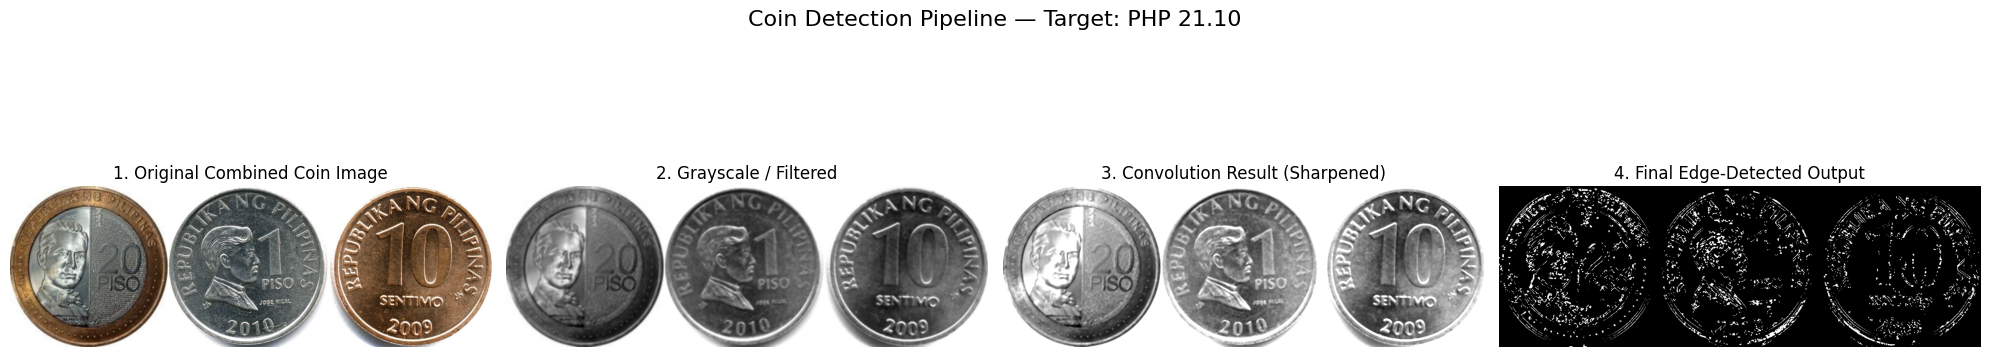

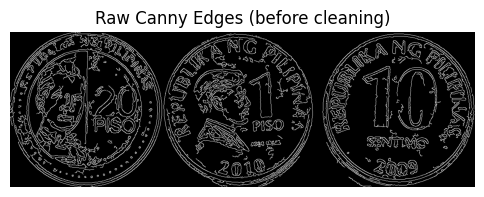

In [ ]:
if __name__ == "__main__":
    COIN_FILENAMES = [
        "coin_20.jpg",
        "coin_1.jpg",
        "coin_0.10.jpg",
    ]
    COIN_IMAGE_PATHS = [os.path.join(IMAGE_DIR, f) for f in COIN_FILENAMES]

    display_pipeline(COIN_IMAGE_PATHS)